In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. EDA

## 1.1. Estandarizacion de los datos

Abrimos el conjunto de datos.

In [2]:
path = '../data/raw/telco.csv'
df = pd.read_csv(path)
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Estandarizamos los valores de las variables categóricas para que tengan un formato consistente y sean más fáciles de analizar.

In [3]:
df = df.replace({'Yes': 'yes',
                'No': 'no',
                'Month-to-month': 'monthly',
                'One year': '1y',
                'Two year': '2y',
                'Electronic check': 'echeck',
                'Mailed check': 'mcheck',
                'Credit card (automatic)': 'ccard',
                'Bank transfer (automatic)': 'btransfer',
                'DSL': 'dsl',
                'Fiber optic': 'fiber'
               })

Para evitar categorias redundantes reemplazamos "No internet service" y "No phone service" por "no".

In [4]:
df = df.replace({"No phone service": "no",
                'No internet service': 'no'})

Para mayor comodidad y una mejor trazabilidad vamos a renombrar sus columnas, indicando tambien el tipo de dato de cada variable.

In [5]:
df = df.rename(columns={"customerID": "s_id", # A unique ID that identifies each customer
                        "gender": "b_gender", # Gender of the customer
                        "SeniorCitizen": "b_senior", # Whether the customer is a senior citizen
                        "Partner": "b_partner", # Whether the customer has a partner
                        "tenure": "i_tenure", # Indicates the total amount of months that the customer has been with the company by the end of the quarter specified above.
                        "Dependents": "b_dependents", # Whether the customer has dependents
                        "PhoneService": "b_phone", # Whether the customer has phone service
                        "MultipleLines": "b_mphone", # Whether the customer has multiple lines
                        "InternetService": "c_internet", # Internet service provider
                        "OnlineSecurity": "b_onlinesec", # Whether the customer has online security
                        "OnlineBackup": "b_onlineback", # Whether the customer has online backup
                        "DeviceProtection": "b_devprot", # Whether the customer has device protection
                        "TechSupport": "b_techsup", # Whether the customer has tech support
                        "Contract": "c_contract", # Contract type of the customer
                        "StreamingTV": "b_streamingtv", # Whether the customer has streaming TV
                        "StreamingMovies": "b_streamingmovies", # Whether the customer has streaming movies
                        "PaperlessBilling": "b_eticket", # Whether the customer has paperless billing
                        "PaymentMethod": "c_paymethod", # Payment method of the customer
                        "MonthlyCharges": "f_monthly", # Monthly charges of the customer
                        "TotalCharges": "f_total", # Total charges of the customer
                        "Churn": "b_churn", # Whether the customer has churned
                        })

## 1.2. Conversion de tipos

Aseguramos que el tipo de datos de las columnas es el correcto.

In [6]:
truthy = {"male","yes","1"}
falsy  = {"female","no","0"}

for col in df.columns:
    if col.startswith("b_"):
        s = df[col]
        ser = s.astype(str).str.strip().str.lower()
        #df[col] = ser
        df[col] = ser.map(lambda x: 1 if x in truthy else (0 if x in falsy else pd.NA)).astype("Int8")
        
    elif col.startswith("f_"):
        df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)  # nullable float

    elif col.startswith("i_"):
        df[col] = pd.to_numeric(df[col], errors="coerce").round(0).astype(int)  # nullable int

    elif col.startswith("c_"):
        df[col] = df[col].astype("string").astype(str)

    elif col.startswith("s_"):
        df[col] = df[col].astype(str)

In [7]:
df.dtypes

s_id                  object
b_gender                Int8
b_senior                Int8
b_partner               Int8
b_dependents            Int8
i_tenure               int64
b_phone                 Int8
b_mphone                Int8
c_internet            object
b_onlinesec             Int8
b_onlineback            Int8
b_devprot               Int8
b_techsup               Int8
b_streamingtv           Int8
b_streamingmovies       Int8
c_contract            object
b_eticket               Int8
c_paymethod           object
f_monthly            float64
f_total              float64
b_churn                 Int8
dtype: object

## 1.3. Eliminacion de columnas irrelevantes

Comprobamos si hay duplicados en base a la columna que a priori deberia ser la clave primaria.

In [8]:
duplicados = df[df.duplicated(subset='s_id', keep=False)]

duplicados

,s_id,b_gender,b_senior,b_partner,b_dependents,i_tenure,b_phone,b_mphone,c_internet,b_onlinesec,...,b_devprot,b_techsup,b_streamingtv,b_streamingmovies,c_contract,b_eticket,c_paymethod,f_monthly,f_total,b_churn


Por si acaso, nos asuguramos que la columna identificadora es unica.

In [9]:
df["s_id"].is_unique

True

La verdad es que la columna identificadora no es necesaria para la solucion del problema, la descartamos.

In [10]:
df = df.drop(columns=["s_id"])

## 1.4. Imputacion de valores faltantes

Estudiamos la cantidad de valores faltantes y de valores atipicos que hay en cada variable.

In [11]:
def stats_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Devuelve una tabla con:
      - missing: nº de NaNs por columna
      - pct: porcentaje de NaNs sobre el total de filas
      - outliers: nº de outliers (IQR*1.5) por columna (solo numéricas)
      - outliers_pct: porcentaje de outliers sobre los valores NO nulos

    Nota:
      - Para columnas no numéricas, outliers y outliers_pct se dejan en NaN.
      - Si IQR==0, se asume 0 outliers.
    """
    # Missing
    na = df.isna().sum()
    pct = (na / len(df)).round(4) if len(df) else pd.Series(np.nan, index=df.columns)

    # Inicializa outliers como NaN para todas las columnas
    outliers_count = pd.Series(np.nan, index=df.columns, dtype="float64")
    outliers_pct = pd.Series(np.nan, index=df.columns, dtype="float64")

    # Detecta outliers por IQR en columnas numéricas
    num_cols = df.select_dtypes(include=["number"]).columns
    k = 1.5  # factor IQR
    for c in num_cols:
        s = pd.to_numeric(df[c], errors="coerce").dropna()
        n = len(s)
        if n == 0:
            outliers_count[c] = 0
            outliers_pct[c] = np.nan
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        if iqr == 0:
            outliers_count[c] = 0
            outliers_pct[c] = 0.0
            continue
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        m = (s < lower) | (s > upper)
        cnt = int(m.sum())
        outliers_count[c] = cnt
        outliers_pct[c] = round(cnt / n, 4)

    out = pd.DataFrame({
        "missing": na,
        "missing_pct": pct,
        "outliers": outliers_count,
        "outliers_pct": outliers_pct
    }).sort_values("missing_pct", ascending=False)

    return out

df_stats = stats_table(df)
df_stats

,missing,missing_pct,outliers,outliers_pct
f_total,11,0.0016,0.0,0.0
b_gender,0,0.0000,0.0,0.0
b_partner,0,0.0000,0.0,0.0
b_senior,0,0.0000,0.0,0.0
b_dependents,0,0.0000,0.0,0.0
i_tenure,0,0.0000,0.0,0.0
b_mphone,0,0.0000,0.0,0.0
b_phone,0,0.0000,0.0,0.0
b_onlinesec,0,0.0000,0.0,0.0
b_onlineback,0,0.0000,0.0,0.0


Vemos que solo hay una columna que presente valores faltantes. Y que ninguna presenta outliers.

## 1.5 Distribuciones de los datos

Estudiaremos como se distribuyen las variables. Para saber de antemano donde poner el foco en el caso de las categoricas, vamos a construir una funcion que nos diga el nivel de desbalanceo en cada variable.

In [12]:
def resumen_desbalanceo_categoricas(
    df, cat_cols, *,
    top_share_umbral=0.8,
    ratio_umbral=10,
    entropia_norm_umbral=0.5,
    hhi_norm_umbral=0.5,
):
    filas = []

    for col in cat_cols:
        s = df[col]
        counts = s.value_counts(dropna=False)
        n = int(counts.sum())
        k = len(counts)

        props = counts / n
        top_idx = props.idxmax()
        top_share = props.loc[top_idx]
        # excluir ceros para min_share
        positive = props[props > 0]
        min_share = positive.min() if len(positive) else np.nan
        ratio = (top_share / min_share) if (k > 1 and min_share > 0) else np.inf

        # Entropía (sin épsilon)
        H = float(-(positive * np.log(positive)).sum())
        entropia_norm = (H / np.log(k)) if k > 1 else 0.0

        # HHI y normalización
        hhi = float((props**2).sum())
        if k > 1:
            hhi_min = 1.0 / k
            hhi_norm = (hhi - hhi_min) / (1.0 - hhi_min)
        else:
            hhi_norm = 1.0

        imbalanced = (
            (top_share >= top_share_umbral) or
            (np.isfinite(ratio) and ratio >= ratio_umbral) or
            (entropia_norm <= entropia_norm_umbral) or
            (hhi_norm >= hhi_norm_umbral)
        )

        row = {
            "feature": col,
            "n": n, "k": k,
            "top_category": top_idx,
            "top_share": top_share,
            "min_share": min_share if np.isfinite(min_share) else np.nan,
            "ratio": ratio if np.isfinite(ratio) else np.nan,
            "entropia_norm": entropia_norm,
            "hhi": hhi,
            "hhi_norm": hhi_norm,
            "imbalanced": bool(imbalanced),
        }

        filas.append(row)

    return pd.DataFrame(filas).sort_values(["imbalanced","hhi_norm","top_share"], ascending=[False, False, False]).reset_index(drop=True).round(2)


lista = []
for col in df.columns:
    if col.startswith("c_") or col.startswith("b_"):
        lista.append(col)

df_des = resumen_desbalanceo_categoricas(df, lista, top_share_umbral=0.8,
                                    ratio_umbral=10, entropia_norm_umbral=0.5,
                                    hhi_norm_umbral=0.5)

df_des

,feature,n,k,top_category,top_share,min_share,ratio,entropia_norm,hhi,hhi_norm,imbalanced
0,b_phone,7043,2,1,0.90,0.10,9.33,0.46,0.83,0.65,True
1,b_senior,7043,2,0,0.84,0.16,5.17,0.64,0.73,0.46,True
2,b_churn,7043,2,0,0.73,0.27,2.77,0.83,0.61,0.22,False
3,b_onlinesec,7043,2,0,0.71,0.29,2.49,0.86,0.59,0.18,False
4,b_techsup,7043,2,0,0.71,0.29,2.45,0.87,0.59,0.18,False
5,b_dependents,7043,2,0,0.70,0.30,2.34,0.88,0.58,0.16,False
6,c_contract,7043,3,monthly,0.55,0.21,2.63,0.91,0.40,0.11,False
7,b_devprot,7043,2,0,0.66,0.34,1.91,0.93,0.55,0.10,False
8,b_onlineback,7043,2,0,0.66,0.34,1.90,0.93,0.55,0.10,False
9,b_streamingtv,7043,2,0,0.62,0.38,1.60,0.96,0.53,0.05,False


Vemos que en las categoricas hay dos variables (b_phone y b_senior) a las que habra que prestarles una mayor atencion. El dataset está desbalanceado en cuanto a la variable objetivo: aproximadamente 26.5% de los clientes churn (se dieron de baja) frente a 73.5% que no.

In [13]:
TARGET = "b_churn"
CAT_COLS = [col for col in df.columns if col.startswith('c_') and col != TARGET]
NUM_COLS = [col for col in df.columns if col.startswith('f_') or col.startswith('i_') and col != TARGET]
BIN_COLS = [col for col in df.columns if col.startswith('b_') and col != TARGET]
STR_COLS = [col for col in df.columns if col.startswith('s_') and col != TARGET]

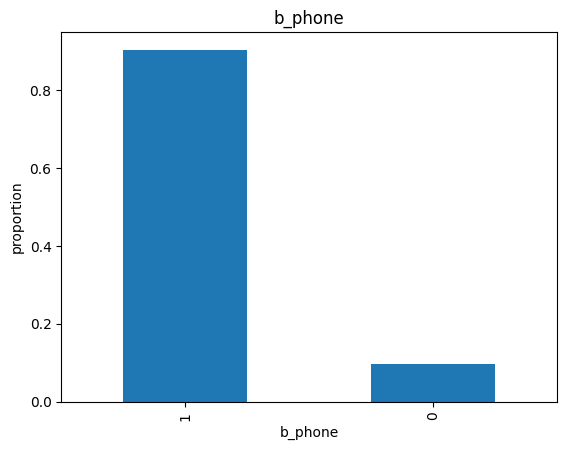

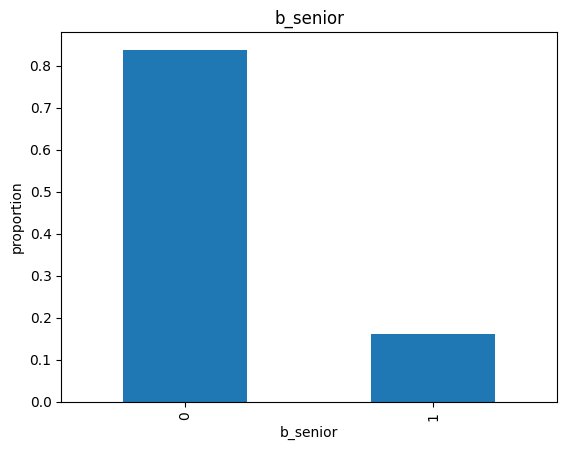

In [14]:
def plot_bar_counts(s: pd.Series) -> None:
    plt.figure()
    vc = s.value_counts(normalize=True)
    vc.plot(kind="bar")
    plt.title(f"{s.name}")
    plt.ylabel("proportion")
    filepath = f"../reports/figures/01_eda_05_{s.name}_bar.png"
    plt.savefig(filepath, bbox_inches="tight")
    plt.show()

for col in ['b_phone', 'b_senior']:
    plot_bar_counts(df[col])

Vemos que la variable objetivo esta desbalanceada.

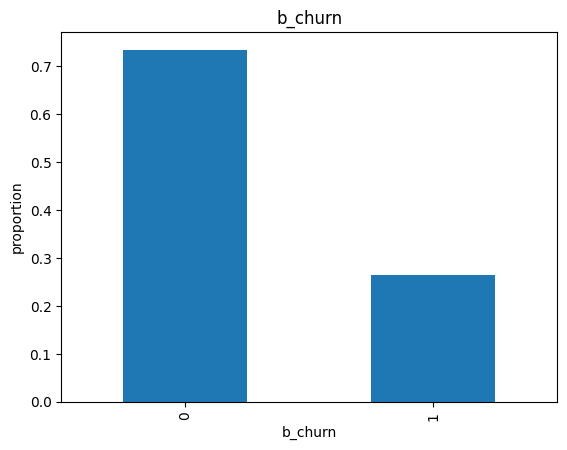

In [15]:
plot_bar_counts(df[TARGET])

Las tres variables numericas tienen distribucion asimetrica.

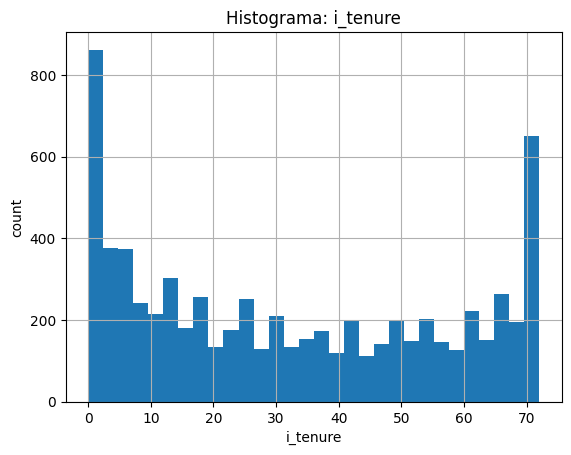

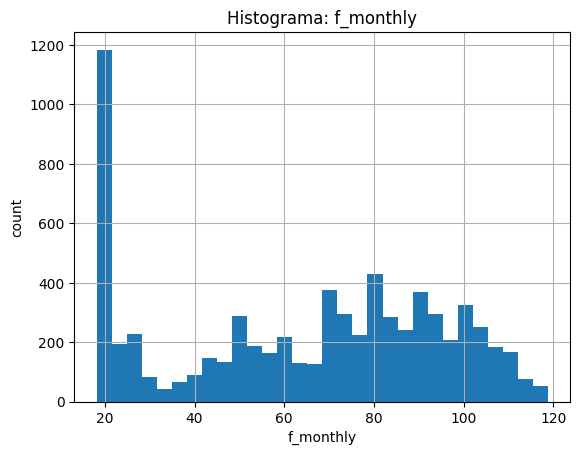

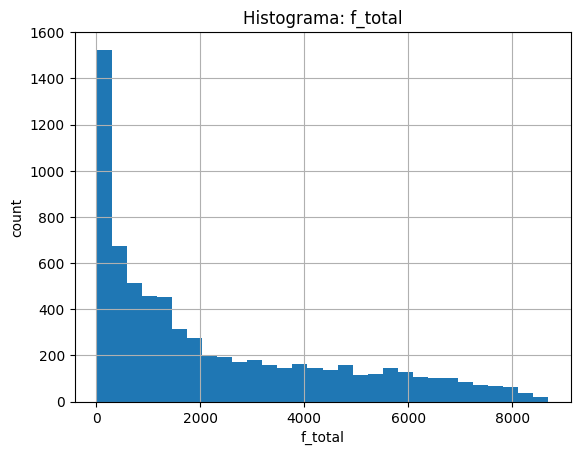

In [16]:
def plot_hist(s: pd.Series, bins: int = 30, title: str | None = None) -> None:
    plt.figure()
    s.dropna().hist(bins=bins)
    plt.title(title or f"Histograma: {s.name}")
    plt.xlabel(str(s.name))
    plt.ylabel("count")
    filepath = f"../reports/figures/01_eda_05_{s.name}_hist.png"
    plt.savefig(filepath, bbox_inches="tight")
    plt.show()


for col in NUM_COLS:
    plot_hist(df[col], bins=30, title=f"Histograma: {col}")

## 1.6. Correlaciones

Estudiamos la correlacion de las variables binarias entre ellas.

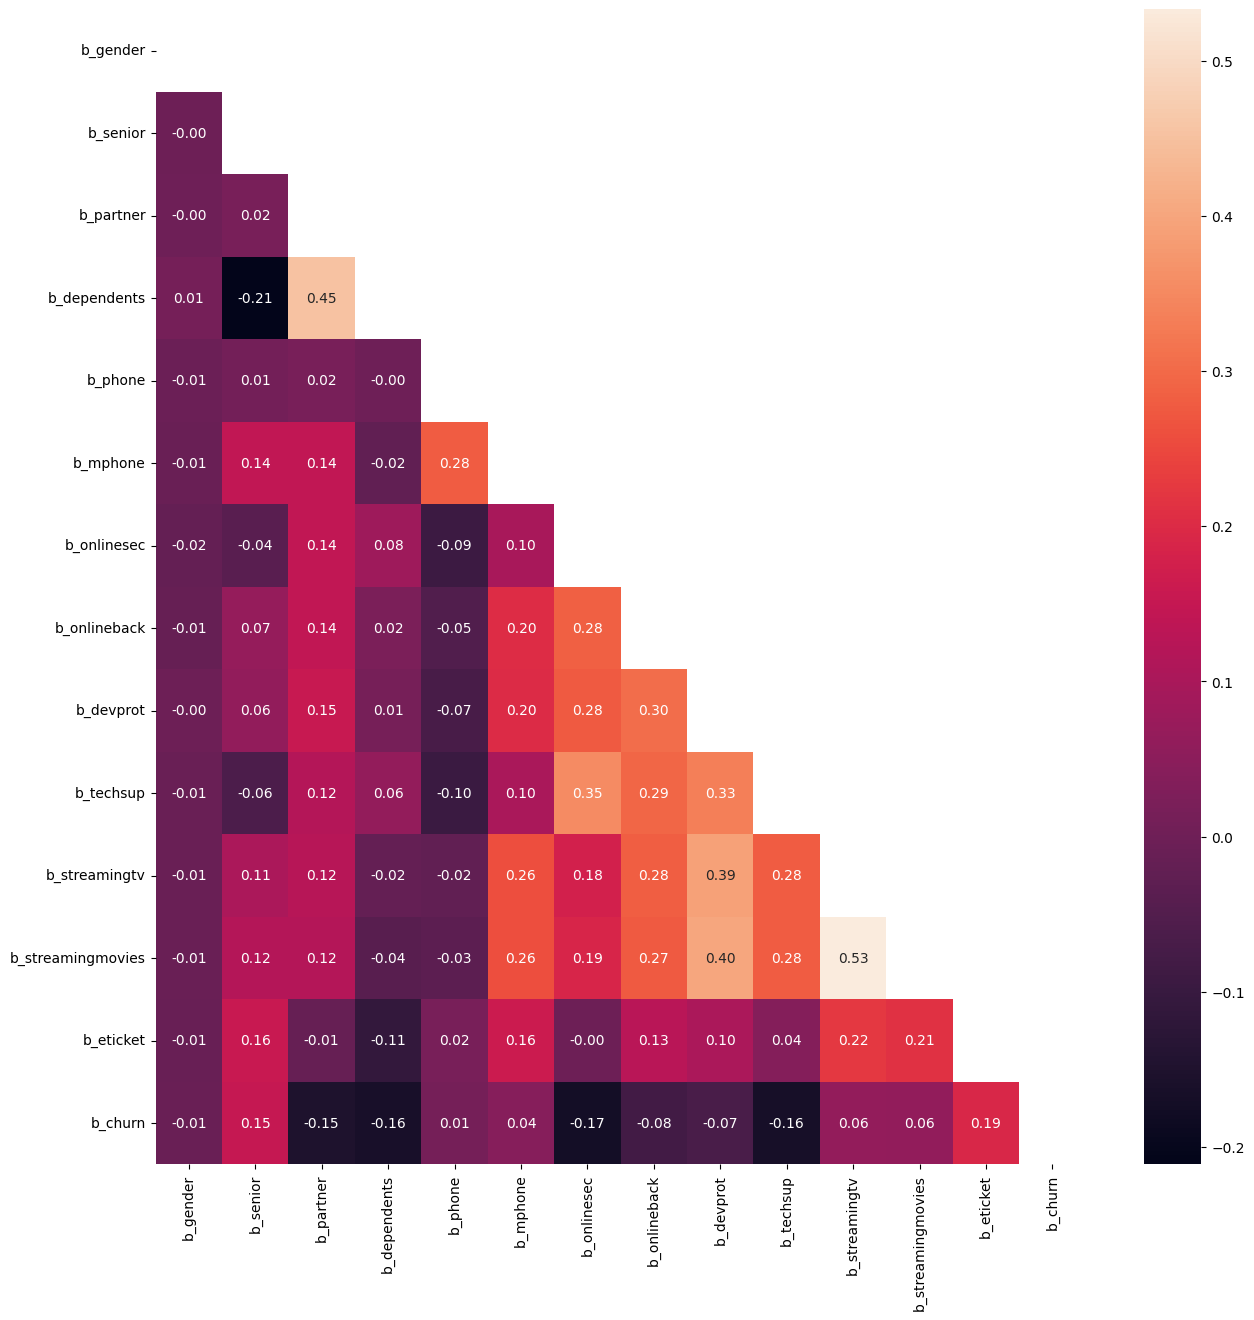

In [17]:
df2 = df[[col for col in df.columns if col in BIN_COLS or col == TARGET]]
mask = np.triu(df2.corr())
fig, ax = plt.subplots(figsize=(15,15))
sns.heatmap(data=df2.corr(), annot=True, fmt=".2f", ax=ax, mask=mask)
filepath = "../reports/figures/01_eda_06_correlation_heatmap.png"
plt.savefig(filepath, bbox_inches="tight")


Ninguna parece presentar colinealidad, pero tampoco vemos una correlacion muy alta de las covariables con la variable objetivo.

## 1.7. Dataset final

In [18]:
df.to_excel("../data/preprocessed/telco_preprocessed.xlsx", index=False)